# Stock Price Forecasting with LSTM









In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.holiday import USFederalHolidayCalendar, GoodFriday

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
tf.get_logger().setLevel("ERROR")

print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.21.0 | GPU: []


In [2]:
WINDOW_SIZE = 5
HORIZON = 1
TEST_DAYS = 365
VAL_FRACTION = 0.10
EPOCHS = 80
BATCH_SIZE = 32
PATIENCE = 20

DATA_DIR = REPO_ROOT / "data"
OUTPUT_DIR = REPO_ROOT / "outputs"
MODEL_DIR = OUTPUT_DIR / "model_experiments"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FILES = {"AAPL": str(DATA_DIR / "AAPL.csv"), "AMD": str(DATA_DIR / "AMD.csv")}
DATA_DIR

'data'

## Exploratory Data Analysis dan Preprocessing

## Memuat data dan melihat bentuknya

Tiap file dipangkas ke kolom Date dan Close, diurutkan menurut tanggal, dan baris Close kosong dibuang.

In [3]:
data = {}
for ticker, path in FILES.items():
    df = pd.read_csv(path, parse_dates=["Date"])
    df = df[["Date", "Close"]].sort_values("Date")
    data[ticker] = df
    print(ticker, df.shape, "|", df["Date"].min().date(), "->", df["Date"].max().date(),
          "| null:", int(df["Close"].isnull().sum()))
data["AAPL"].head()

AAPL (9909, 2) | 1980-12-12 -> 2020-04-01 | null: 0
AMD (10098, 2) | 1980-03-17 -> 2020-04-01 | null: 0


,Date,Close
0,1980-12-12,0.513393
1,1980-12-15,0.486607
2,1980-12-16,0.450893
3,1980-12-17,0.462054
4,1980-12-18,0.475446


## Karakteristik data

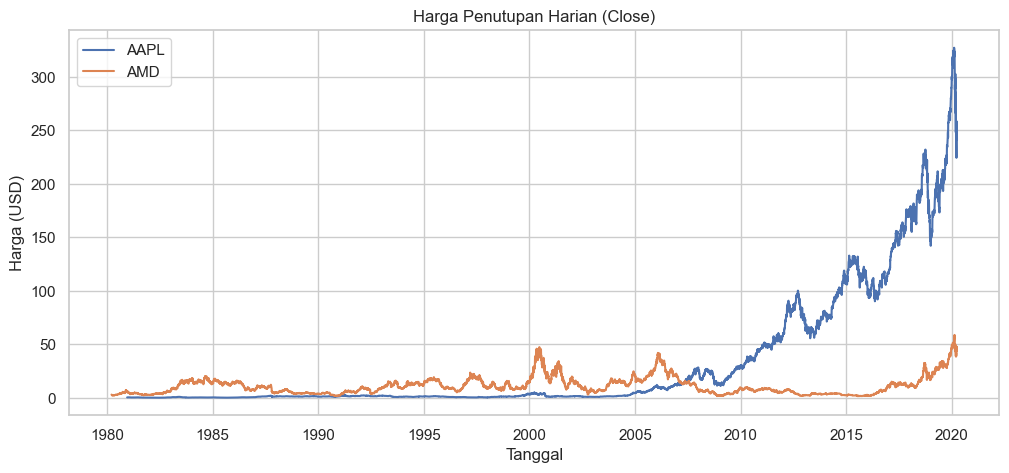

,AAPL,AMD
count,9909.000000,10098.000000
mean,32.618030,11.210802
std,58.471899,8.283645
min,0.196429,1.620000
25%,1.071429,4.937500
50%,1.732143,9.062500
75%,35.761429,14.707500
max,327.200012,58.900002


In [4]:
plt.figure(figsize=(12, 5))
for ticker, df in data.items():
    plt.plot(df["Date"], df["Close"], label=ticker)
plt.title("Harga Penutupan Harian (Close)")
plt.xlabel("Tanggal")
plt.ylabel("Harga (USD)")
plt.legend()
plt.show()

pd.concat({ticker: df["Close"].describe() for ticker, df in data.items()}, axis=1)

Tiap saham dilatih terpisah dan punya scaler sendiri, jadi penskalaan ini per saham, bukan buat menyamakan AAPL dengan AMD. Harga saham cenderung volatil dengan range yang besar, jadi Close tiap ticker dinormalisasi ke [0, 1] pakai MinMaxScaler sendiri-sendiri.

## Kelengkapan Tanggal

Pasar saham tutup tiap akhir pekan dan hari libur, jadi gap antar baris yang wajar itu 1 hari (hari bursa berikutnya) atau 3 hari (Jumat ke Senin); gap 2 atau 4 hari biasanya hari libur yang jatuh di tengah atau pinggir pekan. Yang perlu dicurigai cuma gap besar yang tidak biasa, tanda data benar-benar bolong. Tetapi jika memang terdeteksi libur tidak jadi masalah, tetapi jika memang dataset ini kurang lengkap nantinya akan dicoba imputasi.

Di bawah dihitung sebaran ukuran gap, jumlah hari bursa per tahun, jeda terpanjang, dan berapa weekday yang tidak punya data (hari libur bursa).

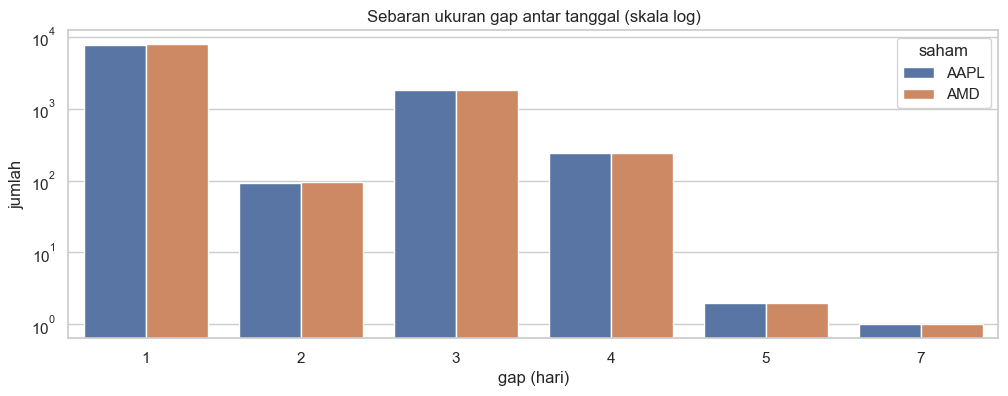

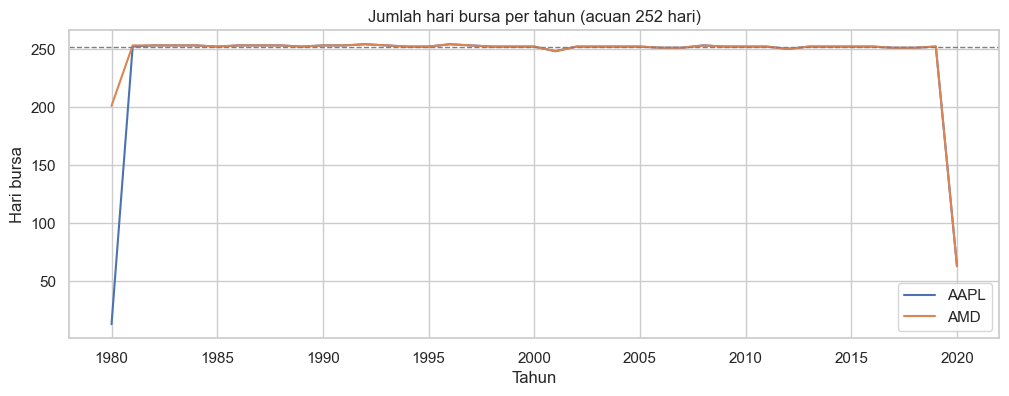

AAPL | hari bursa: 9909 | weekday tanpa data (libur): 345 | jeda terpanjang: 7 hari
AMD | hari bursa: 10098 | weekday tanpa data (libur): 350 | jeda terpanjang: 7 hari


In [5]:
gaps = pd.DataFrame({t: df["Date"].diff().dt.days.dropna().astype(int).value_counts() for t, df in data.items()}).sort_index()
gaps.index.name = "gap (hari)"
gaps_long = gaps.reset_index().melt(id_vars="gap (hari)", var_name="saham", value_name="jumlah")
plt.figure(figsize=(12, 4))
sns.barplot(data=gaps_long, x="gap (hari)", y="jumlah", hue="saham")
plt.yscale("log")
plt.title("Sebaran ukuran gap antar tanggal (skala log)")
plt.show()

per_year = pd.DataFrame({t: df.groupby(df["Date"].dt.year).size() for t, df in data.items()})
plt.figure(figsize=(12, 4))
for t in per_year.columns:
    plt.plot(per_year.index, per_year[t], label=t)
plt.axhline(252, ls="--", color="gray", linewidth=1)
plt.title("Jumlah hari bursa per tahun (acuan 252 hari)")
plt.xlabel("Tahun")
plt.ylabel("Hari bursa")
plt.legend()
plt.show()

for t, df in data.items():
    libur = pd.bdate_range(df["Date"].min(), df["Date"].max()).difference(df["Date"])
    print(t, "| hari bursa:", len(df), "| weekday tanpa data (libur):", len(libur),
          "| jeda terpanjang:", int(df["Date"].diff().dt.days.max()), "hari")

In [6]:
for t, df in data.items():
    big = df.assign(jeda=df["Date"].diff().dt.days).nlargest(5, "jeda")[["Date", "jeda"]]
    print(t, "- 5 jeda terpanjang:")
    print(big.to_string(index=False))

AAPL - 5 jeda terpanjang:
      Date  jeda
2001-09-17   7.0
2007-01-03   5.0
2012-10-31   5.0
1981-02-17   4.0
1981-04-20   4.0
AMD - 5 jeda terpanjang:
      Date  jeda
2001-09-17   7.0
2007-01-03   5.0
2012-10-31   5.0
1980-04-07   4.0
1980-05-27   4.0


Jeda-jeda ini akan dicocokan dengan hari libur bursa amerika dari library USFederalHolidayCalendar dan GoodFriday.

In [7]:
libur_resmi = USFederalHolidayCalendar().holidays(return_name=True)

for t, df in data.items():
    miss = pd.bdate_range(df["Date"].min(), df["Date"].max()).difference(df["Date"])
    gf = GoodFriday.dates(df["Date"].min(), df["Date"].max())
    cocok = miss.isin(libur_resmi.index).mean()*100
    penutupan = miss.difference(libur_resmi.index).difference(gf)
    print(t, "weekday kosong:", len(miss), "| cocok libur federal: %.0f persen" % cocok,
          "| Good Friday:", len(miss.intersection(gf)), "| penutupan satu kali:", len(penutupan))
    print("rincian libur federal yang cocok:")
    print(libur_resmi.reindex(miss).dropna().value_counts().to_string())
    print("penutupan satu kali (di luar libur federal dan Good Friday):")
    print(pd.DataFrame({"tanggal": penutupan.strftime("%Y-%m-%d"), "hari": penutupan.day_name()}).to_string(index=False))
    print()

AAPL weekday kosong: 345 | cocok libur federal: 85 persen | Good Friday: 39 | penutupan satu kali: 12
rincian libur federal yang cocok:
Christmas Day                          40
Washington's Birthday                  40
Memorial Day                           39
Independence Day                       39
Thanksgiving Day                       39
Labor Day                              39
New Year's Day                         35
Birthday of Martin Luther King, Jr.    23
penutupan satu kali (di luar libur federal dan Good Friday):
   tanggal      hari
1981-08-10    Monday
1985-09-27    Friday
1994-04-27 Wednesday
2001-09-11   Tuesday
2001-09-12 Wednesday
2001-09-13  Thursday
2001-09-14    Friday
2004-06-11    Friday
2007-01-02   Tuesday
2012-10-29    Monday
2012-10-30   Tuesday
2018-12-05 Wednesday
AMD weekday kosong: 350 | cocok libur federal: 85 persen | Good Friday: 40 | penutupan satu kali: 12
rincian libur federal yang cocok:
Memorial Day                           40
Independence Day 

Terbukti hari libur, bukan asumsi. Secara keseluruhan sekitar 85 persen tanggal yang lompat persis cocok dengan kalender libur federal AS. Sisa mismatch-nya mayoritas Good Friday (libur bursa yang memang bukan libur federal), dan belasan penutupan satu kali. Setelah dicari, tanggal-tanggal tersebut memang benar bursa ditutup:

- 27 September 1985: Badai Gloria menutup bursa ([CBS News](https://www.cbsnews.com/news/a-look-back-at-other-stock-market-closures/)).
- 27 April 1994: hari berkabung nasional, pemakaman Presiden Nixon ([Deseret News](https://www.deseret.com/1994/4/26/19105533/major-markets-will-close-to-honor-nixon/)).
- 11 sampai 14 September 2001: serangan 11 September, bursa tutup empat hari ([Wikipedia NYSE](https://en.wikipedia.org/wiki/New_York_Stock_Exchange)).
- 11 Juni 2004: hari berkabung nasional, pemakaman Presiden Reagan ([NBC News](https://www.nbcnews.com/id/wbna5157726)).
- 2 Januari 2007: hari berkabung nasional, pemakaman Presiden Ford ([CBS News](https://www.cbsnews.com/news/stock-markets-to-close-for-fords-funeral/)).
- 29 sampai 30 Oktober 2012: Badai Sandy ([Wikipedia](https://en.wikipedia.org/wiki/Hurricane_Sandy)).
- 5 Desember 2018: hari berkabung nasional, pemakaman Presiden Bush ([Wikipedia](https://en.wikipedia.org/wiki/Death_and_state_funeral_of_George_H._W._Bush)).
- 4 November 1980 (cuma muncul di AMD karena data AAPL baru mulai Desember 1980): Election Day 1980, salah satu hari pemilu terakhir yang masih ditutup bursa ([The Seattle Times](https://www.seattletimes.com/business/how-the-stock-market-has-performed-on-election-day/)).

Tinggal satu yang bukan hari libur: 10 Agustus 1981 (Senin) di AAPL. Tanggal ini ada di tabel AAPL tapi tidak di AMD, jadi AMD tetap berdagang dan bursa memang buka. 

Setelah dicrosscheck, pada sumber data lain, tanggal ini memang melompat untuk saham AAPL walau tidak tersedia informasi lebih lanjut.

PAda TradingView dengan date range tool, 1 bar dari 7 Agustus (Jumat) berjarak 4 hari dan langsung ke 11 Agustus (Selasa), jadi 10 Agustus tidak punya bar di sana juga. Tidak diimputasi karena bukan hilang melainkan kemungkinan besar tidak ada perdagangan di hari itu, ditambah hanya satu baris yang hilang dari ribuan baris.

Jadi 100 persen hari yang hilang sudah teridentifikasi, deretnya lengkap sebagai kalender hari bursa dan tidak perlu imputasi.

## Distribusi harga dan return harian

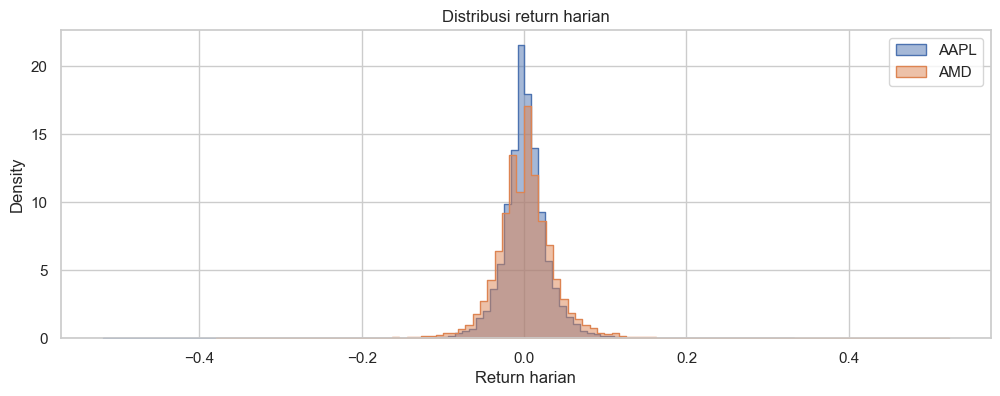

,AAPL,AMD
count,9908.000000,10097.000000
mean,0.001041,0.000976
std,0.028738,0.037787
min,-0.518692,-0.379310
25%,-0.013320,-0.018519
50%,0.000000,0.000000
75%,0.014744,0.019608
max,0.332278,0.522901


In [8]:
ret = pd.DataFrame({t: df["Close"].pct_change() for t, df in data.items()})
plt.figure(figsize=(12, 4))
for t in ret.columns:
    sns.histplot(ret[t].dropna(), bins=100, alpha=0.5, label=t, stat="density", element="step")
plt.title("Distribusi return harian")
plt.xlabel("Return harian")
plt.legend()
plt.show()
ret.describe()

Return harian AAPL dan AMD berpusat di sekitar nol dengan adanya beberapa nilai ekstrem di kedua ujungnya. Saham AMD memiliki volatilitas lebih tinggi dibanding AAPL, ditunjukkan oleh kurva yang lebih lebar dan nilai std yang lebih besar (0.0378 vs 0.0287). Meskipun rata-rata return harian keduanya mirip di dekat nol, AMD mencatat lonjakan tertinggi yang lebih besar (max 0.5229), sedangkan AAPL mencatat penurunan harian yang lebih dalam (min -0.5187).

## Rolling volatility dan pola musiman

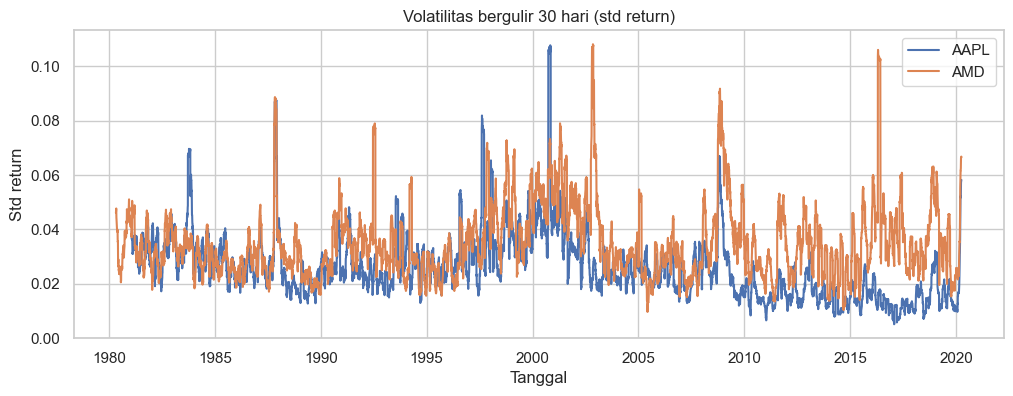

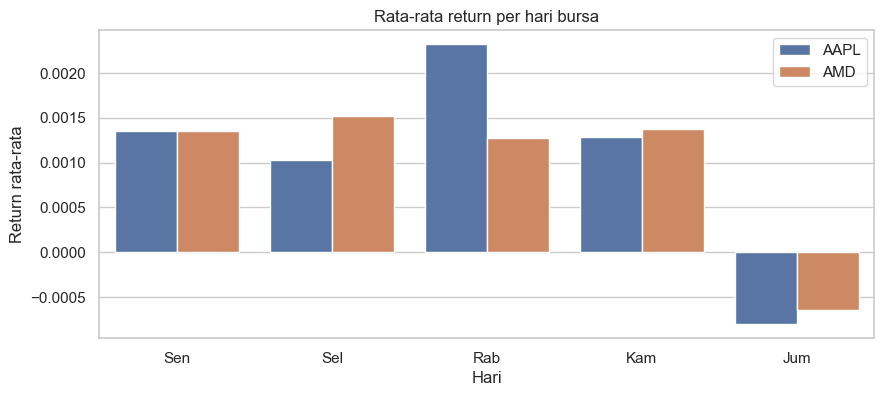

In [9]:
vol = pd.DataFrame({t: df.set_index("Date")["Close"].pct_change().rolling(30).std() for t, df in data.items()})
plt.figure(figsize=(12, 4))
for t in vol.columns:
    plt.plot(vol.index, vol[t], label=t)
plt.title("Volatilitas bergulir 30 hari (std return)")
plt.xlabel("Tanggal")
plt.ylabel("Std return")
plt.legend()
plt.show()

dow = pd.DataFrame({t: df.assign(ret=df["Close"].pct_change()).groupby(df["Date"].dt.dayofweek)["ret"].mean() for t, df in data.items()})
dow = dow[dow.index < 5]
dow.index = ["Sen", "Sel", "Rab", "Kam", "Jum"]
dow.index.name = "hari"
dow_long = dow.reset_index().melt(id_vars="hari", var_name="saham", value_name="ret")
plt.figure(figsize=(10, 4))
sns.barplot(data=dow_long, x="hari", y="ret", hue="saham")
plt.title("Rata-rata return per hari bursa")
plt.xlabel("Hari")
plt.ylabel("Return rata-rata")
plt.legend()
plt.show()

Saham AMD secara konsisten menunjukkan volatilitas yang lebih tinggi daripada AAPL sepanjang waktu, sementara rata-rata return harian keduanya positif dari Senin hingga Kamis dengan puncak tertinggi AAPL di hari Rabu dan AMD di hari Selasa, lalu berbalik negatif secara signifikan pada hari Jumat.

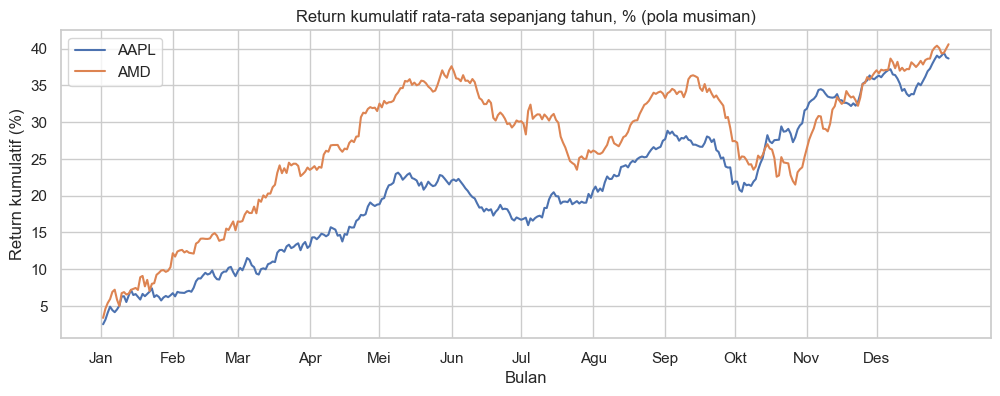

In [10]:
season = pd.DataFrame({t: df.assign(ret=df["Close"].pct_change()).groupby(df["Date"].dt.dayofyear)["ret"].mean().cumsum()*100 for t, df in data.items()})
plt.figure(figsize=(12, 4))
for t in season.columns:
    plt.plot(season.index, season[t], label=t)
plt.xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335],
           ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun", "Jul", "Agu", "Sep", "Okt", "Nov", "Des"])
plt.title("Return kumulatif rata-rata sepanjang tahun, % (pola musiman)")
plt.xlabel("Bulan")
plt.ylabel("Return kumulatif (%)")
plt.legend()
plt.show()

Tren return kumulatif rata-rata menunjukkan saham AMD tumbuh lebih agresif dan mendominasi AAPL dari Januari hingga Oktober sebelum akhirnya kedua saham menutup tahun bersamaan dengan keuntungan tertinggi sekitar 38% hingga 41% di bulan Desember.

## Train/test split, windowing, dan train/validation split

Lalu dipotong jadi window 5 hari dengan label harga close di trading day berikutnya (horizon 1). window masuk test kalau labelnya jatuh di periode test. Test diambil dari 365 hari terakhir. Train dibagi 90:10 tanpa shuffle, karena di time series kita tidak boleh pakai masa depan buat memvalidasi masa lalu.

In [11]:
def make_windows(series, window=WINDOW_SIZE, horizon=HORIZON):
    X, y = [], []
    for i in range(len(series) - window - horizon + 1):
        X.append(series[i:i + window])
        y.append(series[i + window:i + window + horizon])
    return np.array(X), np.array(y)
    
prepared = {}
for ticker, df in data.items():
    cutoff = df["Date"].max() - pd.Timedelta(days=TEST_DAYS)
    n_train = int((df["Date"] <= cutoff).sum())

    scaler = MinMaxScaler()
    scaler.fit(df[["Close"]].iloc[:n_train])
    full_scaled = scaler.transform(df[["Close"]]).flatten()

    X_all, y_all = make_windows(full_scaled)
    target_pos = np.arange(WINDOW_SIZE, WINDOW_SIZE + len(y_all))
    test_mask = target_pos >= n_train

    X_train_all, y_train_all = X_all[~test_mask], y_all[~test_mask]
    n_val = int(len(X_train_all)*VAL_FRACTION)

    X_train, X_val, X_test = X_train_all[:-n_val], X_train_all[-n_val:], X_all[test_mask]
    y_train, y_val, y_test = y_train_all[:-n_val], y_train_all[-n_val:], y_all[test_mask]

    prepared[ticker] = {
        "scaler": scaler,
        "X_train": np.expand_dims(X_train, -1), "y_train": y_train,
        "X_val": np.expand_dims(X_val, -1), "y_val": y_val,
        "X_test": np.expand_dims(X_test, -1), "y_test": y_test,
        "test_df": df.iloc[n_train:],
    }
    print(ticker, "train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

AAPL train: (8687, 5) val: (965, 5) test: (252, 5)
AMD train: (8857, 5) val: (984, 5) test: (252, 5)


## Arsitektur Baseline

Sesuai ketentuan: satu LSTM 50 unit (ReLU) lalu Dense 1 unit sebagai output regresi. Optimizer-nya Adam (default yang paling umum dipakai) dan loss MSE karena ini regresi nilai kontinu, dengan konteks harga yang volatil sehingga per

In [12]:
def build_baseline():
    model = Sequential([
        Input(shape=(WINDOW_SIZE, 1)),
        LSTM(50, activation="relu"),
        Dense(1),
    ], name="baseline_lstm")
    model.compile(loss="mse", optimizer=tf.keras.optimizers.Adam())
    return model

baseline_models, baseline_hist = {}, {}
for ticker, p in prepared.items():
    tf.keras.utils.set_random_seed(SEED)
    model = build_baseline()
    baseline_hist[ticker] = model.fit(
        p["X_train"], p["y_train"],
        validation_data=(p["X_val"], p["y_val"]),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
    )
    baseline_models[ticker] = model

baseline_models["AAPL"].summary()

Epoch 1/80


272/272 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0023 - val_loss: 4.8295e-04


Epoch 2/80


272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.2432e-05 - val_loss: 3.1457e-04


Epoch 3/80


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

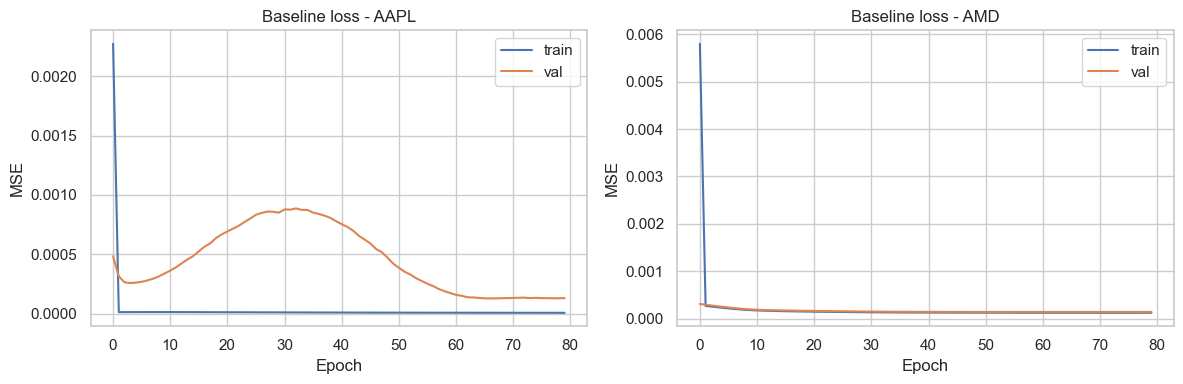

In [13]:
plt.figure(figsize=(12, 4))
for i, ticker in enumerate(prepared, 1):
    plt.subplot(1, 2, i)
    h = baseline_hist[ticker].history
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], label="val")
    plt.title("Baseline loss - " + ticker)
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
plt.tight_layout()
plt.show()

Kurva loss baseline menunjukkan overfitting pada saham AAPL karena train loss langsung anjlok mendekati nol sementara val loss melonjak naik, berbeda dengan saham AMD yang menunjukkan pola pembelajaran sehat karena kedua kurva loss turun bersamaan lalu mendatar hingga epoch terakhir.

## Arsitektur Modifikasi

Modifikasi (menjawab overfit yang kelihatan di baseline):
- **Early stopping + restore_best_weights**, latihan berhenti di val loss terendah dan bobot yang sudah overfit langsung dibuang.
- **Arsitektur dicari pakai Keras Tuner, bukan ditebak manual**, grid search dengan objektif val_loss, jadi kombinasi dipilih dari validation bukan test, tiap saham dapat kombinasi terbaiknya lalu dilatih ulang. Yang di-tuning: unit LSTM {64, 128}, dropout {0.0, 0.3}, learning rate {1e-2, 1e-3}, optimizer {Adam, RMSprop}, activation tetap ReLU seperti baseline.

In [14]:
def build_modified(hp):
    units = hp.Choice("units", [64, 128])
    dropout = hp.Choice("dropout", [0.0, 0.3])
    optimizer = hp.Choice("optimizer", ["adam", "rmsprop"])
    lr = hp.Choice("learning_rate", [1e-2, 1e-3])
    opt = tf.keras.optimizers.Adam(lr) if optimizer == "adam" else tf.keras.optimizers.RMSprop(lr)
    model = Sequential([
        Input(shape=(WINDOW_SIZE, 1)),
        LSTM(units, activation="relu"),
        Dropout(dropout),
        Dense(1),
    ], name="modified_lstm")
    model.compile(loss="mse", optimizer=opt)
    return model

modified_models, modified_hist, modified_hp = {}, {}, {}
for ticker, p in prepared.items():
    tf.keras.utils.set_random_seed(SEED)
    tuner = kt.GridSearch(
        build_modified, objective="val_loss", seed=SEED,
        directory=str(MODEL_DIR), project_name="lstm_" + ticker, overwrite=True)
    tuner.search(
        p["X_train"], p["y_train"], validation_data=(p["X_val"], p["y_val"]),
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0,
        callbacks=[EarlyStopping(patience=PATIENCE, restore_best_weights=True)])
    best_hp = tuner.get_best_hyperparameters(1)[0]
    modified_hp[ticker] = best_hp

    tf.keras.utils.set_random_seed(SEED)
    model = build_modified(best_hp)
    modified_hist[ticker] = model.fit(
        p["X_train"], p["y_train"], validation_data=(p["X_val"], p["y_val"]),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(patience=PATIENCE, restore_best_weights=True)])
    modified_models[ticker] = model
    print(ticker, "HP terbaik:", {k: best_hp.get(k) for k in ["units", "dropout", "optimizer", "learning_rate"]})

modified_models["AAPL"].summary()

Epoch 1/80


272/272 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012


272/272 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.9687e-04 - val_loss: 2.5782e-04


Epoch 2/80


272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.8329e-05 - val_loss: 2.7385e-04


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,069 (781.52 KB)

 Trainable params: 66,689 (260.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 133,380 (521.02 KB)

Hasil pemilihan tuner:
- **Dropout cenderung terpilih 0**, early stopping plus learning rate lebih tinggi sudah cukup menahan overfit, jadi regularisasi eksplisit lewat dropout tidak terlalu diperlukan.
- **Learning rate paling menentukan**, laju lebih tinggi bikin LSTM ber-ReLU tidak buru-buru menghafal, val loss tetap rendah, error AAPL turun drastis.
- **Optimizer: Adam untuk kedua saham**, dicari Adam vs RMSprop, tuner memilih Adam berdasarkan validation.

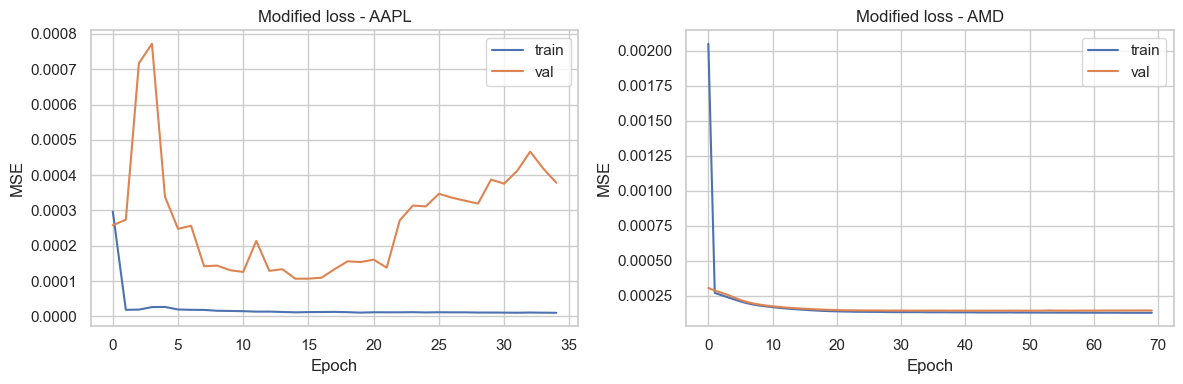

In [15]:
plt.figure(figsize=(12, 4))
for i, ticker in enumerate(prepared, 1):
    plt.subplot(1, 2, i)
    h = modified_hist[ticker].history
    plt.plot(h["loss"], label="train")
    plt.plot(h["val_loss"], label="val")
    plt.title("Modified loss - " + ticker)
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
plt.tight_layout()
plt.show()

Kurva loss modified AAPL memang masih menyisakan tanda overfit: train loss mepet nol sementara val loss sempat turun lalu naik lagi di epoch-epoch akhir. Tapi itu tidak terbawa ke model final, karena restore_best_weights mengembalikan bobot ke titik val loss terendah, bukan bobot epoch terakhir yang sudah overfit, jadi yang dipakai tetap konfigurasi paling general di validation. Ditambah skala error-nya sudah jauh mengecil dibanding baseline, val tertinggi AAPL pun cuma sekitar 0.0008 (MSE pada skala ter-normalisasi), jadi meski grafiknya masih bergelombang tingkat kesalahannya diperkecil dan diambil weight uuntuk titik val paling rendah. AMD tetap berperforma baik dengan besaran error yang semakin kecil, tidak overfit, train dan val berhimpit.

## Evaluasi (RMSE, MAE, MAPE)

Prediksi di-inverse transform dulu ke USD biar RMSE/MAE terbaca sebagai dolar dan MAPE sebagai persen, dihitung di test untuk baseline maupun modifikasi di kedua saham.

In [16]:
def evaluate_preds(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64).flatten()
    y_pred = np.asarray(y_pred, dtype=np.float64).flatten()
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true))*100)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape}
    
rows = []
for ticker, p in prepared.items():
    y_true = p["scaler"].inverse_transform(p["y_test"]).flatten()
    for name, models in [("Baseline", baseline_models), ("Modified", modified_models)]:
        pred = models[ticker].predict(p["X_test"], verbose=0)
        pred = p["scaler"].inverse_transform(pred).flatten()
        rows.append({"Saham": ticker, "Model": name, **evaluate_preds(y_true, pred)})

results = pd.DataFrame(rows).set_index(["Saham", "Model"]).round(4)
results

RMSE     MAE    MAPE
Saham Model                            
AAPL  Baseline  13.1869  8.4632  3.1564
      Modified   6.6812  3.9886  1.6262
AMD   Baseline   1.4455  0.9646  2.5499
      Modified   1.4310  0.9547  2.5370

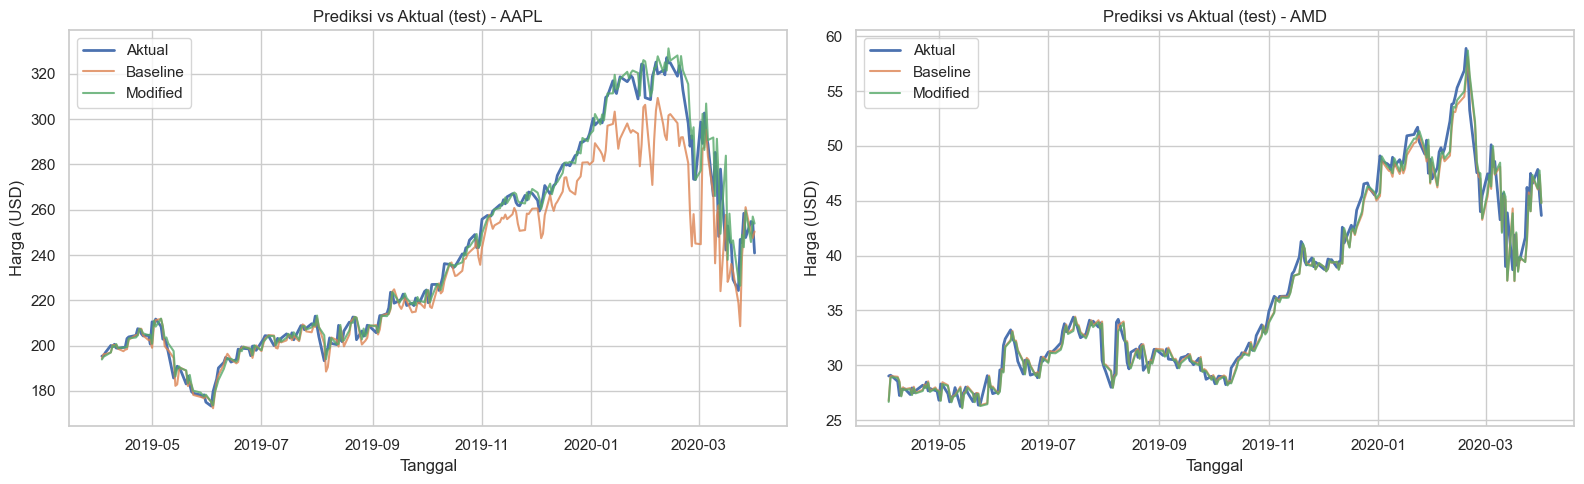

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, ticker in zip(axes, prepared):
    p = prepared[ticker]
    dates = p["test_df"]["Date"].values
    y_true = p["scaler"].inverse_transform(p["y_test"]).flatten()
    base_pred = p["scaler"].inverse_transform(baseline_models[ticker].predict(p["X_test"], verbose=0)).flatten()
    mod_pred = p["scaler"].inverse_transform(modified_models[ticker].predict(p["X_test"], verbose=0)).flatten()
    ax.plot(dates, y_true, label="Aktual", linewidth=2)
    ax.plot(dates, base_pred, label="Baseline", alpha=0.8)
    ax.plot(dates, mod_pred, label="Modified", alpha=0.8)
    ax.set_title("Prediksi vs Aktual (test) - " + ticker)
    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Harga (USD)")
    ax.legend()
plt.tight_layout()
plt.show()

In [18]:
for ticker in prepared:
    sub = results.loc[ticker]
    winner = sub["RMSE"].idxmin()
    print(f"{ticker}: model dengan RMSE terendah = {winner} "
          f"(Baseline RMSE={sub.loc['Baseline', 'RMSE']:.3f}, Modified RMSE={sub.loc['Modified', 'RMSE']:.3f})")

AAPL: model dengan RMSE terendah = Modified (Baseline RMSE=13.187, Modified RMSE=6.681)
AMD: model dengan RMSE terendah = Modified (Baseline RMSE=1.446, Modified RMSE=1.431)


Verdict per saham dicetak otomatis di atas berdasarkan RMSE terendah. Di AAPL modifikasi menang jelas (RMSE dan MAPE turun banyak), LSTM bertumpuk plus dropout membantu di saham berlevel tinggi dengan test bergejolak (awal pandemi 2020). Di AMD praktis seri karena levelnya kecil dan polanya mudah, jadi arsitektur kompleks tidak otomatis lebih baik. Catatan: prediksi 1 hari dengan window pendek cenderung mengekor harga kemarin, jadi kurva yang menempel ke aktual lebih nunjukin harga besok dekat harga hari ini ketimbang model nebak arah.